In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12}) 

# Constantes
eps = 1 
mu = 1 
vp = 1 / np.sqrt(eps * mu)

a = 1 # tamanho da reta (eixo x)
T = 1.5 # tempo de simulação 

kx = np.pi / a
omega = vp * kx

nx_list = [50, 100, 200, 400]
rel_err_by_nx = []

for nx in nx_list:
    dx = a / nx
    dt = dx / 2
    nt = int(T / dt)

    # grids: armazenam os nós 
    # OBS: nx + 1 nós implicam em nx intervalos
    grid_xE = np.linspace(0, a, nx + 1) # xgrid para o Ey ; +1 pois sao nx intervalos de delta x
    grid_tE = np.linspace(0, T, nt + 1) # tgrid para o Ey ; +1 pois sao nt intervalos de delta t

    grid_xH = np.linspace(dx / 2, a - dx / 2, nx) # xgrid para o Hz ; temos nx - 1 intervalos de delta x
    grid_tH = np.linspace(dt / 2, T - dt / 2, nt) # tgrid para o Hz ; temos nt - 1 intervalos de delta t

    E_curr = np.sin(kx * grid_xE) # condicao inicial
    E_next = np.zeros(grid_xE.shape[0])

    H_curr = np.sin(omega * dt/2) * np.cos(kx * grid_xH) # estende a condição inicial para o H
    # H_curr = - (dt / (mu0 * dx)) * (E_curr[1:] - E_curr[:-1])
    H_next = np.zeros(grid_xH.shape[0])

    # snapshots para as fotos
    snapshot_times = np.linspace(0, nt - 1, 6, dtype=int)
    E_snapshots = []
    H_snapshots = []
    E_exact_snapshots = []
    H_exact_snapshots = []

    # marcha no tempo - calculamos o next a cada interação
    error_by_n = []
    for n in range(nt):
        # equações do FDTD 1D
        H_next = H_curr - dt / (mu * dx) * (E_curr[1:] - E_curr[:-1])
        E_next[1:-1] = E_curr[1:-1] - dt / (eps * dx) * (H_next[1:] - H_next[:-1])

        # condição de contorno: PEC nas bordas
        E_next[0] = E_next[-1] = 0

        # Solução exata nos instantes do next, que foram calculados
        E_exact = np.cos(omega * grid_tE[n+1]) * np.sin(kx * grid_xE)
        H_exact = -np.sin(omega * grid_tH[n]) * np.cos(kx * grid_xH)

        # energia da solução exata
        wt = np.sqrt(np.sum((E_exact[:-1]**2 + H_exact**2) * dx))

        # Erro nas normas discretas
        err_E = np.sqrt(dx * np.sum((E_next - E_exact)**2))
        err_H = np.sqrt(dx * np.sum((H_next - H_exact)**2))
        err_total = np.sqrt(err_E**2 + err_H**2)
        error_by_n.append(err_total / wt)

        # tira as fotos
        if n in snapshot_times:
            E_snapshots.append(E_next.copy())
            H_snapshots.append(H_next.copy())
            E_exact_snapshots.append(E_exact.copy())
            H_exact_snapshots.append(H_exact.copy())

        # atualiza o corrente para o proximo passo
        E_curr = E_next
        H_curr = H_next

    rel_err_by_nx.append(np.max(error_by_n))

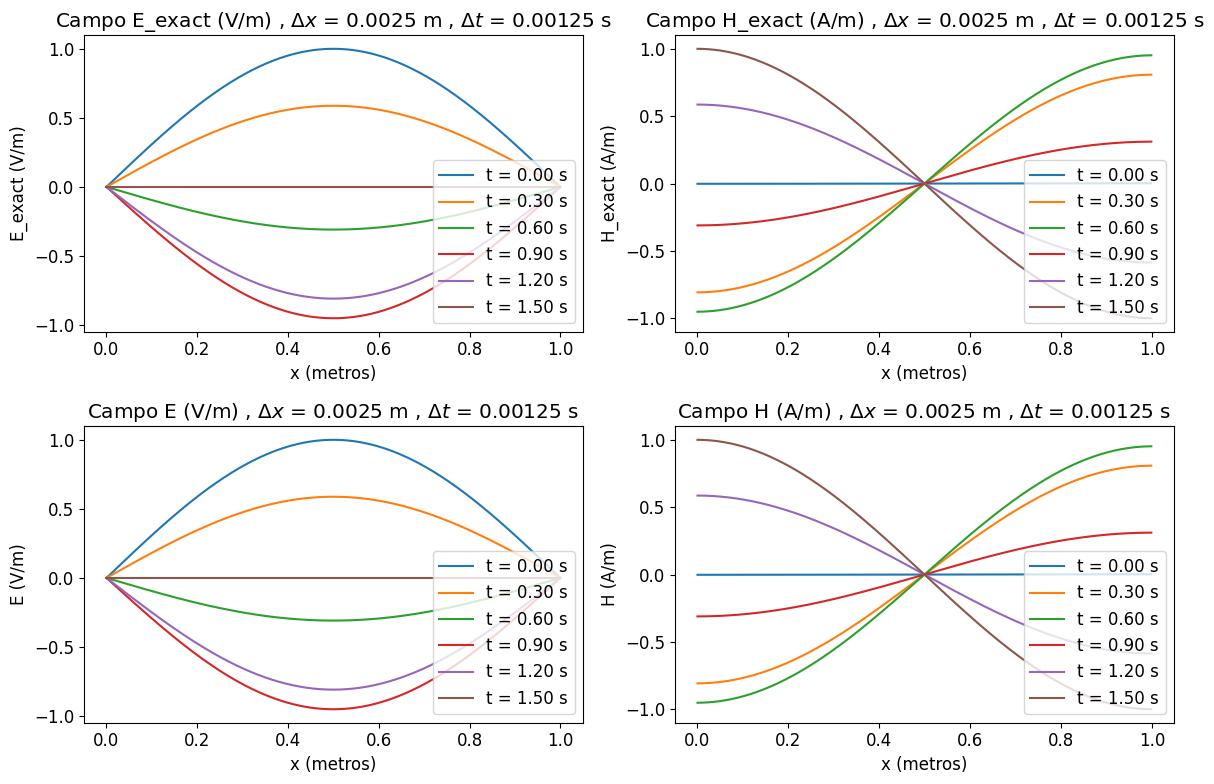

In [6]:
# plota as fotos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for k in range(len(snapshot_times)):
    axes[0,0].plot(grid_xE, E_exact_snapshots[k], label = fr't = {grid_tE[snapshot_times[k]]:.2f} s')
axes[0,0].set_title(fr"Campo E_exact (V/m) , $\Delta x$ = {dx} m , $\Delta t$ = {dt} s")
axes[0,0].set_xlabel("x (metros)")
axes[0,0].set_ylabel(f"E_exact (V/m)")
axes[0,0].legend(loc='lower right')

for k in range(len(snapshot_times)):
    axes[0,1].plot(grid_xH, H_exact_snapshots[k], label = fr't = {grid_tH[snapshot_times[k]]:.2f} s')
axes[0,1].set_title(fr"Campo H_exact (A/m) , $\Delta x$ = {dx} m , $\Delta t$ = {dt} s")
axes[0,1].set_xlabel("x (metros)")
axes[0,1].set_ylabel(f"H_exact (A/m)")
axes[0,1].legend(loc='lower right')


for k in range(len(snapshot_times)):
    axes[1,0].plot(grid_xE, E_snapshots[k], label = fr't = {grid_tE[snapshot_times[k]]:.2f} s')
axes[1,0].set_title(fr"Campo E (V/m) , $\Delta x$ = {dx} m , $\Delta t$ = {dt} s")
axes[1,0].set_xlabel("x (metros)")
axes[1,0].set_ylabel(f"E (V/m)")
axes[1,0].legend(loc='lower right')

for k in range(len(snapshot_times)):
    axes[1,1].plot(grid_xH, H_snapshots[k], label = fr't = {grid_tH[snapshot_times[k]]:.2f} s')
axes[1,1].set_title(fr"Campo H (A/m) , $\Delta x$ = {dx} m , $\Delta t$ = {dt} s")
axes[1,1].set_xlabel("x (metros)")
axes[1,1].set_ylabel(f"H (A/m)")
axes[1,1].legend(loc='lower right')

plt.tight_layout()
plt.show()

0.2495261904154372
0.24977746711309312
0.24989229450940414


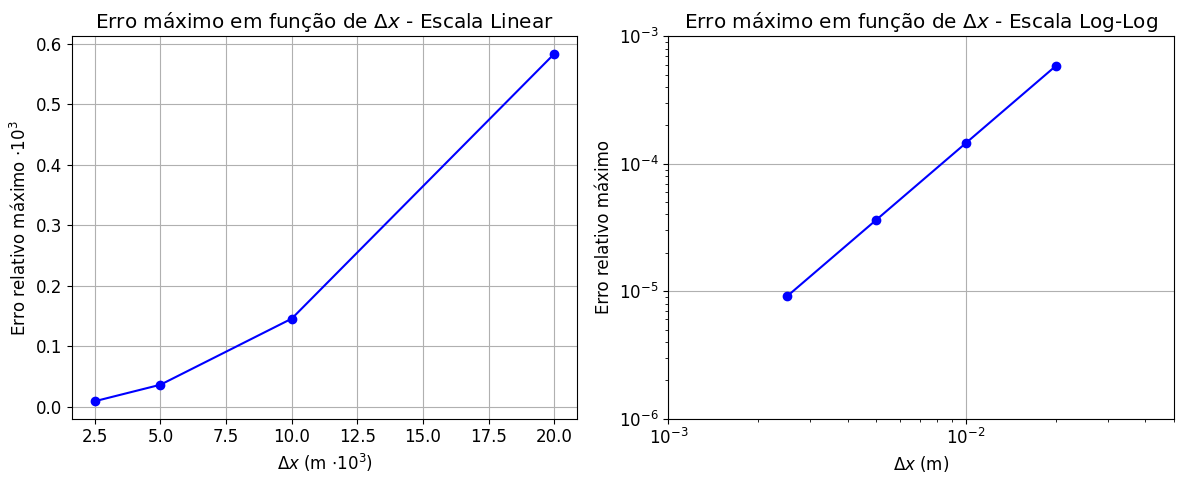

In [13]:
# calcula a ordem
for l in range(len(nx_list) - 1):
    print(rel_err_by_nx[l + 1] / rel_err_by_nx[l])

# plota as fotos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(a / np.array(nx_list) * 1e3, np.array(rel_err_by_nx) * 1e3, color='blue', marker='o')
axes[0].set_title(fr"Erro máximo em função de $\Delta x$ - Escala Linear")
axes[0].set_xlabel(fr"$\Delta x$ (m $\cdot 10^3$)")
axes[0].set_ylabel(fr"Erro relativo máximo $\cdot 10^3$ ")
axes[0].grid()

axes[1].plot(a / np.array(nx_list), rel_err_by_nx, color='blue', marker='o')
axes[1].set_title(fr"Erro máximo em função de $\Delta x$ - Escala Log-Log")
axes[1].set_xlabel(fr"$\Delta x$ (m)")
axes[1].set_ylabel(f"Erro relativo máximo")
axes[1].set_xlim(1e-3, 5e-2)
axes[1].set_ylim(1e-6, 1e-3)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
# calcula a ordem
for l in range(len(nx_list) - 1):
    ratio = rel_err_by_nx[l + 1] / rel_err_by_nx[l]

    print(np.log(ratio) / np.log(0.5))

-0.9622209533896777
-0.9615232947741305
-0.9612047152101133
